In [67]:
##Data exploration

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "Most Streamed Spotify Songs 2024.csv"

In [69]:
### CSV isn't plain UTF-8 some artist/track names use non-UTF-8 characters. Using `latin1` encoding.

df = pd.read_csv(RAW_PATH, encoding='latin1')

df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [70]:
dtype_counts = df.dtypes.value_counts()
print("Column dtype counts as loaded:\n", dtype_counts, "\n")

numeric_as_text_columns = [c for c in df.columns
                           if not pd.api.types.is_numeric_dtype(df[c])
                            and df[c].dropna().astype(str).str.replace(',', '', regex=False).str.match(r'^-?\d+\.?\d*$').all()
                            and c not in ['ISRC']]

print((len(numeric_as_text_columns),"columns have commas"))

print('these columns have commas', numeric_as_text_columns)

Column dtype counts as loaded:
 object     22
float64     6
int64       1
Name: count, dtype: int64 

(17, 'columns have commas')
these columns have commas ['All Time Rank', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Reach', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts']


## Need to clean the comma's from the data

In [71]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '', regex=False), errors='coerce')

for c in numeric_as_text_columns:
    df[c] = clean_numeric(df[c])

print(df[numeric_as_text_columns].dtypes.value_counts())
df[['Spotify Streams', 'YouTube Views', 'Shazam Counts']].head(5)

float64    16
int64       1
Name: count, dtype: int64


,Spotify Streams,YouTube Views,Shazam Counts
0,3.904709e+08,8.427475e+07,2669262.0
1,3.237039e+08,1.163470e+08,1118279.0
2,6.013093e+08,1.225991e+08,5285340.0
3,2.031281e+09,1.096101e+09,11822942.0
4,1.070349e+08,7.737396e+07,457017.0


In [72]:
preview_data = [
    ('Spotify Streams', spotify_streams_preview),
    ('YouTube Views', youtube_views_preview),
    ('YouTube Likes', youtube_likes_preview),
    ('TikTok Posts', tiktok_posts_preview),
    ('TikTok Likes', tiktok_likes_preview),
    ('TikTok Views', tiktok_views_preview),
    ('YouTube Playlist Reach', youtube_playlist_reach_preview),
    ('AirPlay Spins', airplay_spins_preview),
    ('SiriusXM Spins', siriusxm_spins_preview),
    ('Deezer Playlist Reach', deezer_playlist_reach_preview),
    ('Pandora Streams', pandora_streams_preview),
    ('Pandora Track Stations', pandora_track_stations_preview),
    ('Soundcloud Streams', soundcloud_streams_preview),
    ('Shazam Counts', shazam_counts_preview)
]

for name, s in preview_data:
    s_valid = s.dropna()
    q1, med, q3 = s_valid.quantile([0.25, 0.5, 0.75])

    print(f"--- {name} ---")
    print(f"  mean     = {s_valid.mean():,.0f}")
    print(f"  median   = {med:,.0f}")
    print(f"  std      = {s_valid.std():,.0f}")
    print(f"  variance = {s_valid.var():,.0f}")
    print(f"  five-number summary [min, Q1, median, Q3, max] = "
          f"[{s_valid.min():,.0f}, {q1:,.0f}, {med:,.0f}, "
          f"{q3:,.0f}, {s_valid.max():,.0f}]")
    print()

--- Spotify Streams ---
  mean     = 447,387,315
  median   = 239,850,720
  std      = 538,443,905
  variance = 289,921,839,134,544,960
  five-number summary [min, Q1, median, Q3, max] = [1,071, 70,386,298, 239,850,720, 628,363,805, 4,281,468,720]

--- YouTube Views ---
  mean     = 402,796,729
  median   = 148,269,610
  std      = 701,900,001
  variance = 492,663,611,256,547,520
  five-number summary [min, Q1, median, Q3, max] = [913, 40,730,320, 148,269,610, 464,788,240, 16,322,756,555]

--- YouTube Likes ---
  mean     = 2,930,049
  median   = 1,257,935
  std      = 4,593,640
  variance = 21,101,532,683,632
  five-number summary [min, Q1, median, Q3, max] = [25, 409,549, 1,257,935, 3,573,193, 62,311,179]

--- TikTok Posts ---
  mean     = 944,308
  median   = 182,200
  std      = 2,442,080
  variance = 5,963,752,830,586
  five-number summary [min, Q1, median, Q3, max] = [1, 38,186, 182,200, 794,878, 42,900,000]

--- TikTok Likes ---
  mean     = 112,637,465
  median   = 26,534,406
 

In [73]:
print(spotify_streams_preview.head())
print(spotify_streams_preview.dtype)
print(spotify_streams_preview.notna().sum())

0    3.904709e+08
1    3.237039e+08
2    6.013093e+08
3    2.031281e+09
4    1.070349e+08
Name: Spotify Streams, dtype: float64
float64
4487


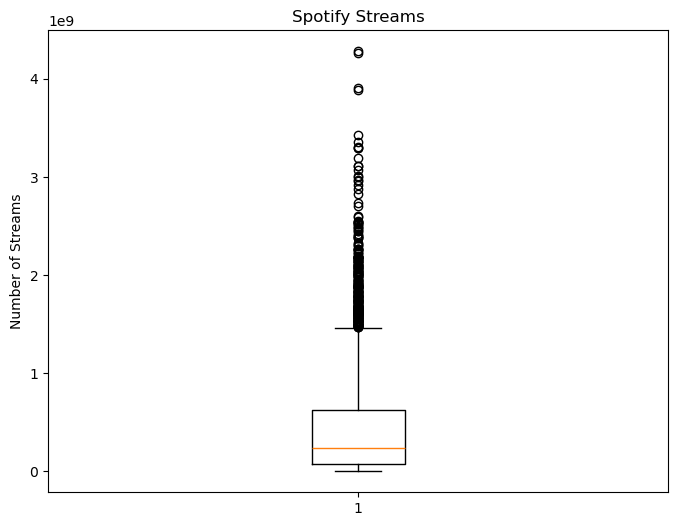

In [74]:
##Boxplot
plt.figure(figsize=(8, 6))

plt.boxplot(spotify_streams_preview.dropna())

plt.title('Spotify Streams')
plt.ylabel('Number of Streams')
plt.show()

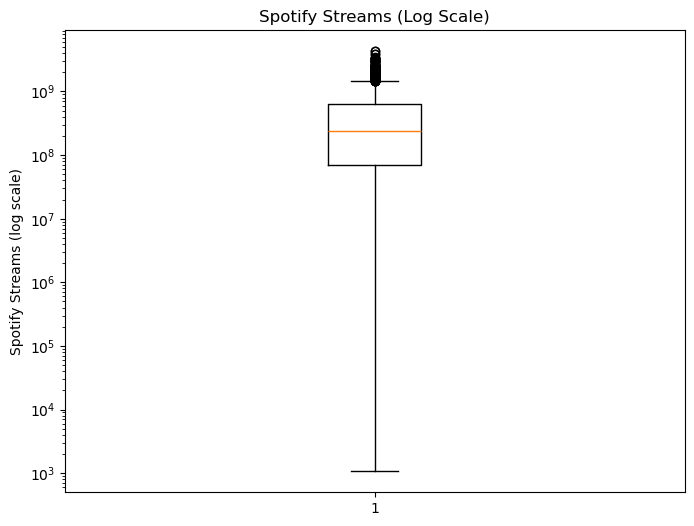

In [75]:
##Log Scale Boxplots

plt.figure(figsize=(8, 6))

plt.boxplot(spotify_streams_preview.dropna())

plt.yscale('log')
plt.title('Spotify Streams (Log Scale)')
plt.ylabel('Spotify Streams (log scale)')
plt.show()

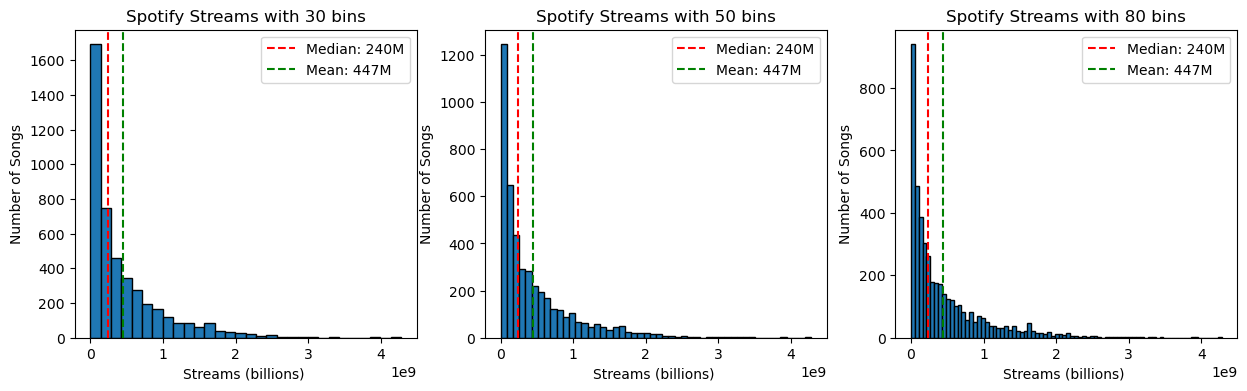

In [76]:
plt.figure(figsize=(15, 4))

for i, bins in enumerate([30,50,80], start=1):
    plt.subplot(1,3,i)
    plt.hist(spotify_streams_preview, bins=bins, edgecolor='black')
    plt.title(f'Spotify Streams with {bins} bins')
    plt.axvline(spotify_streams_preview.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: {spotify_streams_preview.median()/1e6:.0f}M')
    plt.axvline(spotify_streams_preview.mean(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Mean: {spotify_streams_preview.mean()/1e6:.0f}M')
    plt.legend()
    plt.xlabel('Streams (billions) ')
    plt.ylabel('Number of Songs')

Text(0, 0.5, 'Number of Songs')

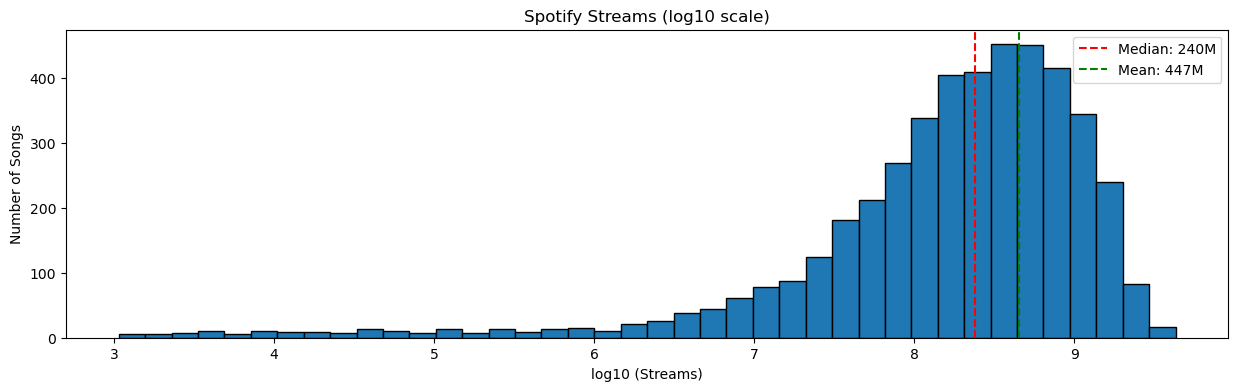

In [77]:
plt.figure(figsize=(15, 4))

median = spotify_streams_preview.median()
mean = spotify_streams_preview.mean()

plt.hist(np.log10(spotify_streams_preview), bins=40, edgecolor='black')
plt.title(f'Spotify Streams (log10 scale)')
plt.axvline(
    np.log10(median),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Median: {median/1e6:.0f}M')
plt.axvline(
    np.log10(mean),
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {mean/1e6:.0f}M'
)
plt.legend()

plt.xlabel('log10 (Streams)')
plt.ylabel('Number of Songs')

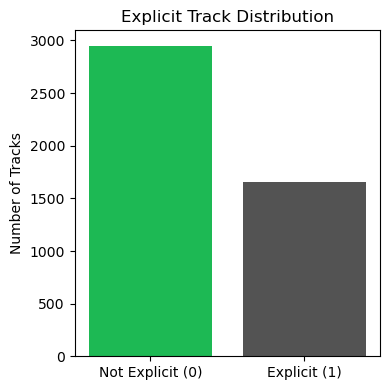

Explicit Track
0    2949
1    1651
Name: count, dtype: int64


In [78]:
explicit_counts = df['Explicit Track'].value_counts().sort_index()

plt.figure(figsize=(4, 4))

plt.bar(
    ['Not Explicit (0)', 'Explicit (1)'],
    explicit_counts.values,
    color=['#1DB954', '#535353']
)

plt.title('Explicit Track Distribution')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(explicit_counts)